# Chess Elo Prediction â€” Transformer Encoder

**Architecture:** Transformer encoder over the move sequence, replacing the BiLSTM in v4.

**Why it might work better:** Self-attention connects any two positions in O(1) â€” a blunder on move 15 and its consequence on move 30 are directly linked without passing information through 14 intermediate hidden states. BiLSTMs have to carry that signal through the whole chain, which degrades with sequence length. Transformers also parallelise fully over the sequence dimension during training.

**Honest tradeoff:** On CPU the Transformer is not obviously faster than a BiLSTM for short sequences (the overhead per attention head is real). The self-attention advantage only kicks in for longer sequences where LSTM memory fades â€” and most chess games are 40â€“80 moves, which LSTMs handle adequately. This architecture may not beat v4's ~200 Elo MAE; it's worth trying because the failure mode (LSTM forgetting distant moves) is plausible but not confirmed as the bottleneck.

**What HPO searches over:** number of attention heads, number of encoder layers, feedforward dimension, dropout.

**Baseline to beat:** v4 combined MAE â‰ˆ 200 Elo.

## Imports

In [1]:
import io, re, os, time, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, normalize
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence

import chess_features_final as cff

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [2]:
# â”€â”€ paths â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
DATA_PATH    = '../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst'
CACHE_DIR    = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)
CKPT_DIR     = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

# â”€â”€ how many games to load â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MAX_GAMES = 3_000_000

# â”€â”€ time-control filter â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
TIME_CONTROL  = None
TC_BASE_MIN   = 600
TC_BASE_MAX   = 600
TC_INC_MIN    = None
TC_INC_MAX    = None
EXCLUDE_TERMS = {'Time forfeit', 'Abandoned', 'Unterminated'}

# â”€â”€ sequence / move settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MIN_PLIES   = 12
MAX_SEQ_LEN = 120

# â”€â”€ model mode: live Transformer over moves, no AE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
USE_SEQUENTIAL = True   # run transformer over move sequence every batch
USE_AE         = False  # no AE â€” transformer handles sequence directly

# â”€â”€ autoencoder settings (kept for AE cache reuse if needed) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
AE_LATENT_DIM  = 32
AE_TRAIN_FRAC  = 0.15
AE_EPOCHS      = 2
AE_MAX_SEQ     = 60
AE_BATCH_SIZE  = 512
AE_MODEL_PATH  = CACHE_DIR / 'seq_autoencoder.pth'

# â”€â”€ distribution target â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
USE_DIST_TARGET = True
N_BINS          = 40
ELO_SIGMA       = 200
BIN_EDGES       = np.arange(0, 4100, 100)
BIN_CENTERS     = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

# â”€â”€ default hyperparameters (overwritten by HPO best trial) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
EMBED_DIM    = 64
HIDDEN_DIM   = 128   # transformer d_model
N_HEADS      = 4     # attention heads
N_LAYERS     = 2     # transformer encoder layers
FF_DIM       = 256   # feedforward dim inside each transformer layer
BATCH_SIZE   = 128
NUM_EPOCHS   = 10
LR           = 3e-4
DROPOUT      = 0.30
WEIGHT_DECAY = 1e-4
PATIENCE     = 3
NUM_WORKERS  = 0
VAL_FRAC     = 0.10
TEST_FRAC    = 0.10

# â”€â”€ HPO settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
HPO_TRIALS    = 15
HPO_GAMES     = 50_000   # subset size for quick HPO runs
HPO_EPOCHS    = 3        # epochs per trial â€” enough to distinguish configs

# â”€â”€ feature groups â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
FEATURE_GROUPS = {
    'game_structure': True,
    'checks':         True,
    'captures':       True,
    'castling':       True,
    'style':          True,
    'engine_quality': True,
    'clock':          True,
    'tc_meta':        True,
}
GROUP_PREFIXES = {
    'game_structure': ['total_ply', 'material_balance', 'result_encoded'],
    'checks':         ['checks_given', 'check_density'],
    'captures':       ['first_capture', 'pawn_captures', 'piece_captures', 'capture_density'],
    'castling':       ['castle_move', 'castle_side'],
    'style':          ['consec_same', 'queen_moves', 'white_territory', 'black_territory',
                       'promotions', 'en_passant', 'legal_moves'],
    'engine_quality': ['acpl', 'inaccuracy', 'mistake', 'blunder'],
    'clock':          ['w_avg_time', 'w_std_time', 'w_max_time', 'w_time_pressure',
                       'w_opening_pace', 'b_avg_time', 'b_std_time', 'b_max_time',
                       'b_time_pressure', 'b_opening_pace'],
    'tc_meta':        ['tc_base', 'tc_inc'],
}
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]

# â”€â”€ device â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP     = (device.type == 'cuda')
CPU_THREADS = os.cpu_count() or 4
torch.set_num_threads(CPU_THREADS)

print(f'Device : {device}  |  AMP : {USE_AMP}  |  CPU threads : {CPU_THREADS}')
print(f'Sequential={USE_SEQUENTIAL}  |  AE={USE_AE}  |  DistTarget={USE_DIST_TARGET}')
print(f'MAX_GAMES={MAX_GAMES:,}  |  N_HEADS={N_HEADS}  |  N_LAYERS={N_LAYERS}  |  FF_DIM={FF_DIM}')
print(f'HPO_TRIALS={HPO_TRIALS}  |  HPO_GAMES={HPO_GAMES:,}  |  HPO_EPOCHS={HPO_EPOCHS}')

Device : cpu  |  AMP : False  |  CPU threads : 12
Sequential=True  |  AE=False  |  DistTarget=True
MAX_GAMES=3,000,000  |  N_HEADS=4  |  N_LAYERS=2  |  FF_DIM=256
HPO_TRIALS=15  |  HPO_GAMES=50,000  |  HPO_EPOCHS=3


## Data Loading

Loaded 3,000,000 games in 246.2s
Removed 1,007,365 games by termination type
Kept 372,502 games after filters (removed 1,611,767)
Elo range — White: 771–2605,  Black: 762–2608


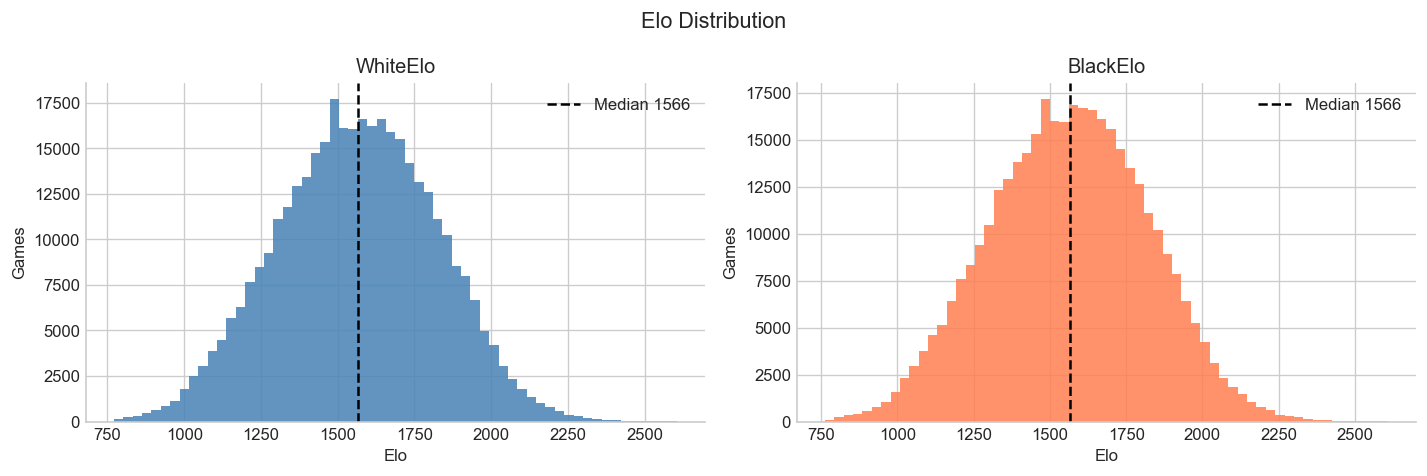

In [3]:
def load_pgn_zst(path, max_games):
    records = []
    with open(path, 'rb') as fh:
        dctx   = zstd.ZstdDecompressor()
        stream = io.TextIOWrapper(dctx.stream_reader(fh), encoding='utf-8', errors='replace')
        headers, moves_lines, in_moves = {}, [], False
        for line in stream:
            line = line.strip()
            if line.startswith('['):
                in_moves = False
                m = re.match(r'\[(\w+)\s+\"(.*)\"\]', line)
                if m: headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers, moves_lines = {}, []
                    if len(records) >= max_games: break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers: moves_lines.append(line)
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)
    return pd.DataFrame(records)


t0     = time.time()
df_raw = load_pgn_zst(DATA_PATH, MAX_GAMES)
print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

for col in ['WhiteElo', 'BlackElo']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df_raw[['WhiteElo', 'BlackElo']] = df_raw[['WhiteElo', 'BlackElo']].astype(int)

if 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMS)].reset_index(drop=True)
    print(f'Removed {before - len(df_raw):,} games by termination type')

tc_pattern = re.compile(r'^(\d+)\+(\d+)')
def parse_tc(tc_str):
    m = tc_pattern.match(str(tc_str))
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)

df_raw[['tc_base', 'tc_inc']] = df_raw['TimeControl'].apply(lambda x: pd.Series(parse_tc(x)))
df_raw.dropna(subset=['tc_base'], inplace=True)
df_raw['tc_base'] = df_raw['tc_base'].astype(int)
df_raw['tc_inc']  = df_raw['tc_inc'].astype(int)

before = len(df_raw)
if TIME_CONTROL: df_raw = df_raw[df_raw['TimeControl'].astype(str) == TIME_CONTROL]
if TC_BASE_MIN:  df_raw = df_raw[df_raw['tc_base'] >= TC_BASE_MIN]
if TC_BASE_MAX:  df_raw = df_raw[df_raw['tc_base'] <= TC_BASE_MAX]
df_raw = df_raw.reset_index(drop=True)

print(f'Kept {len(df_raw):,} games after filters (removed {before - len(df_raw):,})')
print(f'Elo range — White: {df_raw.WhiteElo.min()}–{df_raw.WhiteElo.max()},  '
      f'Black: {df_raw.BlackElo.min()}–{df_raw.BlackElo.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['WhiteElo', 'BlackElo'], ['steelblue', 'coral']):
    ax.hist(df_raw[col], bins=60, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df_raw[col].median(), color='black', lw=1.5, ls='--',
               label=f'Median {df_raw[col].median():.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Games')
    ax.set_title(col); ax.legend()
plt.suptitle('Elo Distribution', fontsize=13)
plt.tight_layout(); plt.show()


## Feature Extraction

In [4]:
CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def extract_clocks(pgn_str):
    return [int(h)*3600 + int(m)*60 + float(s)
            for h, m, s in CLK_RE.findall(pgn_str)]


def clock_features(pgn_str, tc_base):
    clocks = extract_clocks(pgn_str)
    empty  = {k: np.nan for k in [
        'w_avg_time_norm', 'w_std_time_norm', 'w_max_time_norm', 'w_time_pressure', 'w_opening_pace',
        'b_avg_time_norm', 'b_std_time_norm', 'b_max_time_norm', 'b_time_pressure', 'b_opening_pace']}
    if len(clocks) < 4 or tc_base <= 0:
        return empty
    white_clocks = clocks[0::2]
    black_clocks = clocks[1::2]
    def time_spent(clock_list):
        return [max(0., clock_list[i] - clock_list[i+1])
                for i in range(len(clock_list) - 1)] if len(clock_list) > 1 else [0.]
    def player_stats(spent, remaining, tc):
        spent_arr = np.array(spent)
        rem_arr   = np.array(remaining)
        return {
            'avg_time_norm':  float(spent_arr.mean() / tc),
            'std_time_norm':  float(spent_arr.std()  / tc) if len(spent_arr) > 1 else 0.,
            'max_time_norm':  float(spent_arr.max()  / tc),
            'time_pressure':  int(np.sum(rem_arr[1:] < 30)) if len(rem_arr) > 1 else 0,
            'opening_pace':   float(np.mean(spent[:5]) / tc) if len(spent) >= 5
                              else float(spent_arr.mean() / tc),
        }
    white_stats = player_stats(time_spent(white_clocks), white_clocks, tc_base)
    black_stats = player_stats(time_spent(black_clocks), black_clocks, tc_base)
    return {f'w_{k}': v for k, v in white_stats.items()} | {f'b_{k}': v for k, v in black_stats.items()}


cache_key   = f'{len(df_raw)}_{MAX_GAMES}'
board_cache = CACHE_DIR / f'board_{cache_key}.pkl'
clock_cache = CACHE_DIR / f'clock_{cache_key}.pkl'

if board_cache.exists():
    board_feats = pd.read_pickle(board_cache)
    print(f'Board features loaded from cache  ({board_feats.shape[1]} cols)')
else:
    print('Extracting board features (runs once then caches)...')
    t0 = time.time()
    board_feats = cff.extract_features_dataframe(df_raw, n_jobs=-1)
    board_feats.to_pickle(board_cache)
    print(f'  Done in {time.time()-t0:.0f}s â€” {board_feats.shape[1]} cols')

if clock_cache.exists():
    clock_feats = pd.read_pickle(clock_cache)
    print(f'Clock features loaded from cache  ({clock_feats.shape[1]} cols)')
else:
    print('Extracting clock features...')
    t0 = time.time()
    rows = Parallel(n_jobs=-1)(
        delayed(clock_features)(moves, tc)
        for moves, tc in zip(df_raw['Moves'].tolist(), df_raw['tc_base'].tolist()))
    clock_feats = pd.DataFrame(rows, index=df_raw.index)
    clock_feats.to_pickle(clock_cache)
    print(f'  Done in {time.time()-t0:.0f}s â€” {clock_feats.shape[1]} cols')

for side in ['castle_side_white', 'castle_side_black']:
    if side in board_feats.columns:
        dummies     = pd.get_dummies(board_feats[side], prefix=side)
        board_feats = pd.concat([board_feats.drop(columns=[side]), dummies], axis=1)

df = pd.concat([df_raw, board_feats, clock_feats], axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Full feature matrix: {df.shape}')

Extracting board features (runs once then caches)...
  Done in 197s â€” 35 cols
Extracting clock features...
  Done in 13s â€” 10 cols
Full feature matrix: (372502, 69)


## Move Tokenisation

In [5]:
move_to_id = {'<PAD>': 0, '<UNK>': 1}

def add_move(move):
    if move not in move_to_id:
        move_to_id[move] = len(move_to_id)

def encode_move(move):
    return move_to_id.get(move, 1)

def vocab_size():
    return len(move_to_id)


MOVE_RE = re.compile(r'(?:\d+\.+\s*)?([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?|O-O-O[+#]?|O-O[+#]?)')
EVAL_RE = re.compile(r'\[%eval\s+([^\]]+)\]')

def parse_moves(pgn_str):
    moves  = MOVE_RE.findall(pgn_str)
    clocks = extract_clocks(pgn_str)
    evals  = []
    for e in EVAL_RE.findall(pgn_str):
        try:
            evals.append(100. if '#' in e else float(e))
        except ValueError:
            evals.append(0.)
    return moves, clocks, evals


parsed = df['Moves'].apply(parse_moves)
df['clean_moves']  = parsed.apply(lambda x: x[0])
df['clean_clocks'] = parsed.apply(lambda x: x[1])
df['clean_evals']  = parsed.apply(lambda x: x[2])
df['n_moves']      = df['clean_moves'].apply(len)

before = len(df)
df = df[df['n_moves'] >= MIN_PLIES].reset_index(drop=True)
print(f'Dropped {before - len(df):,} games shorter than {MIN_PLIES} plies')

for move_list in df['clean_moves']:
    for move in move_list:
        add_move(move)

print(f'Vocabulary size : {vocab_size():,}')
print(f'Games ready     : {len(df):,}')

Dropped 6,099 games shorter than 12 plies
Vocabulary size : 9,682
Games ready     : 366,403


## Soft Distribution Targets

1600 Elo dist: peak at 1550,  recovered = 1600


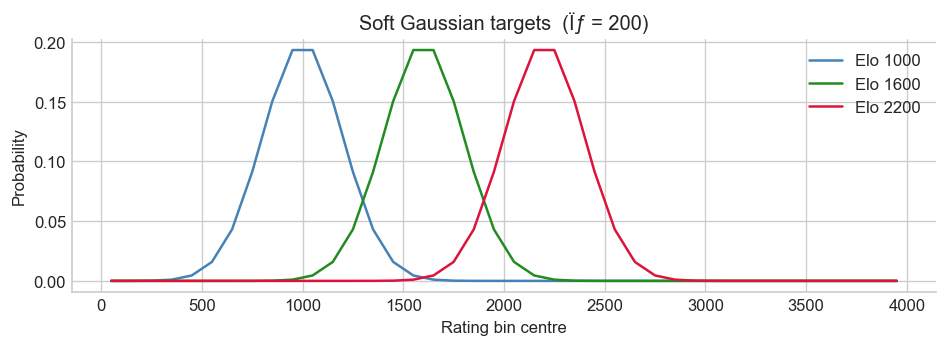

In [6]:
def make_elo_dist(elo, sigma=ELO_SIGMA):
    probs = np.exp(-0.5 * ((BIN_CENTERS - elo) / sigma) ** 2)
    return (probs / probs.sum()).astype(np.float32)

def dist_to_elo(dist):
    return float(np.dot(dist, BIN_CENTERS))

test_dist = make_elo_dist(1600)
print(f'1600 Elo dist: peak at {BIN_CENTERS[test_dist.argmax()]:.0f},  '
      f'recovered = {dist_to_elo(test_dist):.0f}')

fig, ax = plt.subplots(figsize=(8, 3))
for elo, color in [(1000, 'steelblue'), (1600, 'forestgreen'), (2200, 'crimson')]:
    ax.plot(BIN_CENTERS, make_elo_dist(elo), label=f'Elo {elo}', color=color)
ax.set_xlabel('Rating bin centre'); ax.set_ylabel('Probability')
ax.set_title('Soft Gaussian targets  (Ïƒ = 200)')
ax.legend()
plt.tight_layout(); plt.show()

## Feature Selection, Train/Val/Test Split & Scaling

In [7]:
excluded_cols  = {'WhiteElo', 'BlackElo', 'n_moves'}
all_numeric    = [c for c in df.select_dtypes(include=[np.number]).columns
                  if c not in excluded_cols]

active_prefixes = []
for group_name, is_active in FEATURE_GROUPS.items():
    if is_active:
        active_prefixes.extend(GROUP_PREFIXES.get(group_name, []))

static_cols = [c for c in all_numeric
               if any(c.startswith(p) for p in active_prefixes)]
num_static  = len(static_cols)

print(f'Static feature columns selected: {num_static}')

avg_elo    = (df['WhiteElo'] + df['BlackElo']) / 2
elo_strata = pd.cut(avg_elo, bins=ELO_BINS, labels=False).fillna(0).astype(int)

idx_train, idx_temp = train_test_split(
    df.index, test_size=VAL_FRAC + TEST_FRAC,
    stratify=elo_strata, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=elo_strata.loc[idx_temp], random_state=RANDOM_STATE)

print(f'Split â€” train: {len(idx_train):,}  val: {len(idx_val):,}  test: {len(idx_test):,}')

# cast to float64 first â€” tc_base, tc_inc and count columns are int,
# and pandas 2.0 raises LossySetitemError if we write floats into int columns
df[static_cols] = df[static_cols].astype(np.float64)

scaler = StandardScaler()
scaler.fit(df.loc[idx_train, static_cols].fillna(0))
df[static_cols] = scaler.transform(df[static_cols].fillna(0))
print('Scaling done (StandardScaler fit on train only)')

total_static_dim = num_static

Static feature columns selected: 45
Split â€” train: 293,122  val: 36,640  test: 36,641
Scaling done (StandardScaler fit on train only)


## Dataset & DataLoaders

In [8]:
class ChessDataset(Dataset):
    def __init__(self, df_subset, static_cols, use_dist=True):
        self.items    = []
        static_vals   = df_subset[static_cols].fillna(0).values.astype(np.float32)
        for i, (_, row) in enumerate(df_subset.iterrows()):
            tc = max(1, int(row.get('tc_base', 600)))
            move_ids  = [encode_move(m) for m in row['clean_moves'][:MAX_SEQ_LEN]]
            n         = len(move_ids)
            raw_clks  = row['clean_clocks'][:n]
            norm_clks = [min(max(c / tc, 0.), 2.) for c in raw_clks]
            norm_clks += [0.5] * (n - len(norm_clks))
            turn_flags = [float(j % 2) for j in range(n)]
            white_elo  = float(row['WhiteElo'])
            black_elo  = float(row['BlackElo'])
            if use_dist:
                white_target = torch.tensor(make_elo_dist(white_elo), dtype=torch.float32)
                black_target = torch.tensor(make_elo_dist(black_elo), dtype=torch.float32)
            else:
                white_target = torch.tensor([white_elo], dtype=torch.float32)
                black_target = torch.tensor([black_elo], dtype=torch.float32)
            self.items.append({
                'moves':     torch.tensor(move_ids,       dtype=torch.long),
                'clocks':    torch.tensor(norm_clks,      dtype=torch.float32),
                'turns':     torch.tensor(turn_flags,     dtype=torch.float32),
                'static':    torch.tensor(static_vals[i], dtype=torch.float32),
                'white_tgt': white_target,
                'black_tgt': black_target,
                'raw_elo':   torch.tensor([white_elo, black_elo], dtype=torch.float32),
            })

    def __len__(self):    return len(self.items)
    def __getitem__(self, i): return self.items[i]


def collate_games(batch):
    moves_pad  = pad_sequence([b['moves'][:MAX_SEQ_LEN]  for b in batch], batch_first=True, padding_value=0)
    clocks_pad = pad_sequence([b['clocks'][:MAX_SEQ_LEN] for b in batch], batch_first=True, padding_value=0.)
    turns_pad  = pad_sequence([b['turns'][:MAX_SEQ_LEN]  for b in batch], batch_first=True, padding_value=0.)
    return {
        'moves':     moves_pad,
        'clocks':    clocks_pad,
        'turns':     turns_pad,
        'mask':      (moves_pad != 0).float(),
        'static':    torch.stack([b['static']    for b in batch]),
        'white_tgt': torch.stack([b['white_tgt'] for b in batch]),
        'black_tgt': torch.stack([b['black_tgt'] for b in batch]),
        'raw_elo':   torch.stack([b['raw_elo']   for b in batch]),
    }


print('Building datasets...')
t0 = time.time()
train_ds = ChessDataset(df.loc[idx_train], static_cols, USE_DIST_TARGET)
val_ds   = ChessDataset(df.loc[idx_val],   static_cols, USE_DIST_TARGET)
test_ds  = ChessDataset(df.loc[idx_test],  static_cols, USE_DIST_TARGET)
print(f'  Built in {time.time()-t0:.0f}s   static dim = {total_static_dim}')

train_elos     = (df.loc[idx_train, 'WhiteElo'] + df.loc[idx_train, 'BlackElo']) / 2
sample_weights = cff.compute_elo_sample_weights(train_elos, ELO_BINS)
sampler        = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_ds), replacement=True)

loader_kwargs = dict(batch_size=BATCH_SIZE, collate_fn=collate_games,
                     pin_memory=(device.type=='cuda'), num_workers=NUM_WORKERS)
train_loader  = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
val_loader    = DataLoader(val_ds,   shuffle=False,   **loader_kwargs)
test_loader   = DataLoader(test_ds,  shuffle=False,   **loader_kwargs)
print(f'Batches per epoch: {len(train_loader):,}')

Building datasets...
  Built in 73s   static dim = 45
Batches per epoch: 2,291


## Model â€” Transformer Encoder

**Static branch:** same MLP as v4 (LayerNorm + GELU).

**Sequence branch:** token embedding â†’ sinusoidal positional encoding â†’ N-layer Transformer encoder â†’ mean-pool over non-padding positions.

**Fusion:** concat static + sequence vector â†’ shared trunk â†’ two output heads (White/Black, 40 bins each).

The input to each transformer position is `[move_embedding | norm_clock | turn_flag]`, same as v4's LSTM input.

In [ ]:
class SinusoidalPE(nn.Module):
    """Standard sinusoidal positional encoding, added to the token embeddings."""
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


def build_transformer_model(n_vocab, n_static, embed_dim, d_model,
                             n_heads, n_layers, ff_dim, dropout, n_bins):
    """
    Build the Transformer Elo predictor.
    d_model must be divisible by n_heads â€” we enforce this by rounding up.
    """
    # d_model must be divisible by n_heads; round up to nearest multiple
    d_model = math.ceil(d_model / n_heads) * n_heads

    # sequence branch
    move_embed  = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
    input_proj  = nn.Linear(embed_dim + 2, d_model)  # +2: clock + turn flag
    pos_enc     = SinusoidalPE(d_model, max_len=MAX_SEQ_LEN + 1, dropout=dropout * 0.5)
    enc_layer   = nn.TransformerEncoderLayer(
        d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
        dropout=dropout, batch_first=True, norm_first=True)   # pre-norm is more stable
    transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

    # static branch
    static_net = nn.Sequential(
        nn.Linear(n_static, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(128, 64),       nn.GELU(),
        nn.Linear(64,  32),       nn.GELU(),
    )

    # fusion trunk + output heads
    fusion_net = nn.Sequential(
        nn.Linear(d_model + 32, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(256, 128),          nn.GELU(), nn.Dropout(dropout * 0.5),
    )
    white_head = nn.Linear(128, n_bins)
    black_head = nn.Linear(128, n_bins)

    class TransformerEloPredictor(nn.Module):
        def __init__(self):
            super().__init__()
            self.move_embed  = move_embed
            self.input_proj  = input_proj
            self.pos_enc     = pos_enc
            self.transformer = transformer
            self.static_net  = static_net
            self.fusion_net  = fusion_net
            self.white_head  = white_head
            self.black_head  = black_head
            self.d_model     = d_model
            self._init_weights()

        def _init_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                    if m.bias is not None: nn.init.zeros_(m.bias)
                elif isinstance(m, nn.Embedding):
                    nn.init.normal_(m.weight, std=0.02)
                    with torch.no_grad():
                        m.weight[m.padding_idx].fill_(0)

        def encode_sequence(self, moves, clocks, turns, mask):
            # embed moves, concatenate clock and turn flag, project to d_model
            x = self.move_embed(moves)
            x = torch.cat([x, clocks.unsqueeze(-1), turns.unsqueeze(-1)], dim=-1)
            x = self.input_proj(x)   # (B, T, d_model)
            x = self.pos_enc(x)
            # TransformerEncoder expects src_key_padding_mask: True where PADDING
            pad_mask = (mask == 0)   # (B, T), True = pad
            x = self.transformer(x, src_key_padding_mask=pad_mask)
            # mean-pool over non-padding positions
            valid = mask.unsqueeze(-1)           # (B, T, 1)
            ctx   = (x * valid).sum(1) / valid.sum(1).clamp(min=1)
            return ctx

        def forward(self, moves, clocks, turns, mask, static_feats):
            ctx        = self.encode_sequence(moves, clocks, turns, mask)
            static_out = self.static_net(static_feats)
            combined   = torch.cat([ctx, static_out], dim=1)
            hidden     = self.fusion_net(combined)
            white_probs = torch.softmax(self.white_head(hidden), dim=-1)
            black_probs = torch.softmax(self.black_head(hidden), dim=-1)
            attn_dummy  = torch.zeros(moves.size(0), 1, device=moves.device)
            return white_probs, black_probs, attn_dummy

        def game_embedding(self, moves, clocks, turns, mask, static_feats):
            ctx        = self.encode_sequence(moves, clocks, turns, mask)
            static_out = self.static_net(static_feats)
            combined   = torch.cat([ctx, static_out], dim=1)
            return self.fusion_net(combined)

        @staticmethod
        def probs_to_elo(probs):
            bins = torch.tensor(BIN_CENTERS, dtype=probs.dtype, device=probs.device)
            return (probs * bins).sum(dim=-1)

    return TransformerEloPredictor()


# build default model to verify shapes
model = build_transformer_model(
    n_vocab=vocab_size(), n_static=total_static_dim,
    embed_dim=EMBED_DIM, d_model=HIDDEN_DIM, n_heads=N_HEADS,
    n_layers=N_LAYERS, ff_dim=FF_DIM, dropout=DROPOUT, n_bins=N_BINS,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model built {n_params:,} trainable parameters  |  d_model={model.d_model}')

Model built â€” 994,608 trainable parameters  |  d_model=128


## Hyperparameter Optimisation (Optuna)

15 trials on a 50k-game subset, 3 training epochs each. Searches:
- `n_heads`: number of attention heads {4, 8}
- `n_layers`: Transformer encoder depth {2, 4, 6}
- `ff_dim`: feedforward dimension {128, 256, 512}
- `dropout`: regularisation strength {0.1 â€¦ 0.4}

Best hyperparameters are used for the full training run below.

In [ ]:
hpo_cache = CKPT_DIR / 'transformer_hpo_best.pkl'

if hpo_cache.exists():
    import pickle
    best_params = pickle.loads(hpo_cache.read_bytes())
    print(f'HPO cache found â€” best params: {best_params}')
else:
    # build a small subset for fast HPO trials
    hpo_n     = min(HPO_GAMES, len(idx_train))
    hpo_idx   = np.random.default_rng(RANDOM_STATE).choice(idx_train, size=hpo_n, replace=False)
    hpo_idx   = pd.Index(hpo_idx)
    hpo_ds    = ChessDataset(df.loc[hpo_idx], static_cols, USE_DIST_TARGET)
    hpo_ldr   = DataLoader(hpo_ds, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=collate_games, num_workers=NUM_WORKERS)

    kl_loss = nn.KLDivLoss(reduction='batchmean')

    def hpo_objective(trial):
        n_heads  = trial.suggest_categorical('n_heads',  [4, 8])
        n_layers = trial.suggest_categorical('n_layers', [2, 4, 6])
        ff_dim   = trial.suggest_categorical('ff_dim',   [128, 256, 512])
        dropout  = trial.suggest_float('dropout', 0.1, 0.4)
        d_model  = trial.suggest_categorical('d_model',  [64, 128])

        m = build_transformer_model(
            n_vocab=vocab_size(), n_static=total_static_dim,
            embed_dim=64, d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, ff_dim=ff_dim, dropout=dropout, n_bins=N_BINS,
        ).to(device)
        opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-4)

        for _ in range(HPO_EPOCHS):
            m.train()
            for batch in hpo_ldr:
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                static = batch['static'].to(device)
                wp, bp, _ = m(moves, clocks, turns, mask, static)
                loss = (kl_loss(torch.log(wp.clamp(min=1e-9)), batch['white_tgt'].to(device)) +
                        kl_loss(torch.log(bp.clamp(min=1e-9)), batch['black_tgt'].to(device)))
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), 1.)
                opt.step()

        # evaluate on validation set
        m.eval()
        val_loss, n_val = 0., 0
        with torch.no_grad():
            for batch in val_loader:
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                static = batch['static'].to(device)
                wp, bp, _ = m(moves, clocks, turns, mask, static)
                val_loss += (kl_loss(torch.log(wp.clamp(min=1e-9)), batch['white_tgt'].to(device)) +
                             kl_loss(torch.log(bp.clamp(min=1e-9)), batch['black_tgt'].to(device))).item()
                n_val += 1
        del m
        return val_loss / max(n_val, 1)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(hpo_objective, n_trials=HPO_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    print(f'\nBest trial  val_loss={study.best_value:.4f}')
    print(f'Best params: {best_params}')

    import pickle
    hpo_cache.write_bytes(pickle.dumps(best_params))



Best trial: 2. Best value: 0.69755:  33%|███▎      | 5/15 [3:07:01<6:14:02, 2244.26s/it]


[W 2026-06-07 20:04:36,204] Trial 5 failed with parameters: {'n_heads': 4, 'n_layers': 6, 'ff_dim': 512, 'dropout': 0.2070259980080768, 'd_model': 128} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Elias\AppData\Local\Temp\ipykernel_26648\2806051819.py", line 40, in hpo_objective
    wp, bp, _ = m(moves, clocks, turns, mask, static)
                ~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1778, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1789, in _call_impl
    return forward_call(*args, **kwargs)
  File "C:\Users\Elias\

KeyboardInterrupt: 

In [13]:
# apply best params
best_params = study.best_params
print(f'\nBest trial  val_loss={study.best_value:.4f}')
print(f'Best params: {best_params}')
N_HEADS  = best_params.get('n_heads',  N_HEADS)
N_LAYERS = best_params.get('n_layers', N_LAYERS)
FF_DIM   = best_params.get('ff_dim',   FF_DIM)
DROPOUT  = best_params.get('dropout',  DROPOUT)
HIDDEN_DIM = best_params.get('d_model', HIDDEN_DIM)
print(f'\nFull training will use: n_heads={N_HEADS}  n_layers={N_LAYERS}  ff_dim={FF_DIM}  dropout={DROPOUT:.3f}  d_model={HIDDEN_DIM}')


Best trial  val_loss=0.6976
Best params: {'n_heads': 8, 'n_layers': 4, 'ff_dim': 256, 'dropout': 0.28226345557043153, 'd_model': 64}

Full training will use: n_heads=8  n_layers=4  ff_dim=256  dropout=0.282  d_model=64


## Training

In [15]:
model_path = CKPT_DIR / f'transformer_{MAX_GAMES:.0e}.pth'

if model_path.exists():
    print(f'Checkpoint found â€” skipping training. Delete to retrain: {model_path}')
else:
    model = build_transformer_model(
        n_vocab=vocab_size(), n_static=total_static_dim,
        embed_dim=EMBED_DIM, d_model=HIDDEN_DIM, n_heads=N_HEADS,
        n_layers=N_LAYERS, ff_dim=FF_DIM, dropout=DROPOUT, n_bins=N_BINS,
    ).to(device)

    optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LR*0.05)
    amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    kl_loss    = nn.KLDivLoss(reduction='batchmean')

    def compute_loss(white_pred, black_pred, batch):
        wl = torch.log(white_pred.clamp(min=1e-9))
        bl = torch.log(black_pred.clamp(min=1e-9))
        return (kl_loss(wl, batch['white_tgt'].to(device)) +
                kl_loss(bl, batch['black_tgt'].to(device)))

    def preds_to_elo(white_pred, black_pred):
        return (model.probs_to_elo(white_pred).detach().cpu().numpy(),
                model.probs_to_elo(black_pred).detach().cpu().numpy())

    train_losses, val_losses = [], []
    best_val, patience_ctr   = float('inf'), 0

    for epoch in range(NUM_EPOCHS):
        t_ep = time.time()
        model.train()
        running_loss, n_batches = 0., 0
        for batch in train_loader:
            moves  = batch['moves'].to(device, non_blocking=True)
            clocks = batch['clocks'].to(device, non_blocking=True)
            turns  = batch['turns'].to(device, non_blocking=True)
            mask   = batch['mask'].to(device, non_blocking=True)
            static = batch['static'].to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                wp, bp, _ = model(moves, clocks, turns, mask, static)
                loss = compute_loss(wp, bp, batch)
            optimizer.zero_grad(set_to_none=True)
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            running_loss += loss.item(); n_batches += 1
        train_losses.append(running_loss / max(n_batches, 1))
        scheduler.step()

        model.eval()
        val_loss, val_batches = 0., 0
        white_preds, black_preds = [], []
        white_trues, black_trues = [], []
        with torch.no_grad():
            for batch in val_loader:
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                static = batch['static'].to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    wp, bp, _ = model(moves, clocks, turns, mask, static)
                    loss = compute_loss(wp, bp, batch)
                val_loss += loss.item(); val_batches += 1
                ep, ep2 = preds_to_elo(wp, bp)
                white_preds.extend(ep); black_preds.extend(ep2)
                white_trues.extend(batch['raw_elo'][:, 0].numpy())
                black_trues.extend(batch['raw_elo'][:, 1].numpy())

        val_loss /= max(val_batches, 1)
        val_losses.append(val_loss)
        w_mae = mean_absolute_error(white_trues, white_preds)
        b_mae = mean_absolute_error(black_trues, black_preds)
        print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
              f'train {train_losses[-1]:.4f}  val {val_loss:.4f}  '
              f'MAE W:{w_mae:.0f} B:{b_mae:.0f}  '
              f'lr {optimizer.param_groups[0]["lr"]:.2e}  {time.time()-t_ep:.1f}s')

        if val_loss < best_val * (1 - 1e-3):
            best_val, patience_ctr = val_loss, 0
            torch.save({
                'model_state':  model.state_dict(),
                'move_to_id':   move_to_id,
                'static_cols':  static_cols,
                'scaler_mean':  scaler.mean_.tolist(),
                'scaler_std':   scaler.scale_.tolist(),
                'n_heads':      N_HEADS,
                'n_layers':     N_LAYERS,
                'ff_dim':       FF_DIM,
                'dropout':      DROPOUT,
                'd_model':      HIDDEN_DIM,
                'embed_dim':    EMBED_DIM,
                'n_bins':       N_BINS,
                'n_static':     total_static_dim,
            }, model_path)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_losses, label='Train', lw=1.5)
    ax.plot(val_losses,   label='Validation', lw=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Training Curves â€” Transformer')
    ax.legend()
    plt.tight_layout(); plt.show()

KeyboardInterrupt: 

## Evaluation

In [ ]:
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model = build_transformer_model(
    n_vocab=vocab_size(), n_static=total_static_dim,
    embed_dim=checkpoint['embed_dim'], d_model=checkpoint['d_model'],
    n_heads=checkpoint['n_heads'], n_layers=checkpoint['n_layers'],
    ff_dim=checkpoint['ff_dim'], dropout=checkpoint['dropout'], n_bins=checkpoint['n_bins'],
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Loaded checkpoint: {model_path}')

kl_loss = nn.KLDivLoss(reduction='batchmean')

def preds_to_elo(white_pred, black_pred):
    return (model.probs_to_elo(white_pred).detach().cpu().numpy(),
            model.probs_to_elo(black_pred).detach().cpu().numpy())


white_preds, black_preds = [], []
white_trues, black_trues = [], []

with torch.no_grad():
    for batch in test_loader:
        moves  = batch['moves'].to(device)
        clocks = batch['clocks'].to(device)
        turns  = batch['turns'].to(device)
        mask   = batch['mask'].to(device)
        static = batch['static'].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            wp, bp, _ = model(moves, clocks, turns, mask, static)
        ep, ep2 = preds_to_elo(wp, bp)
        white_preds.extend(ep); black_preds.extend(ep2)
        white_trues.extend(batch['raw_elo'][:, 0].numpy())
        black_trues.extend(batch['raw_elo'][:, 1].numpy())

white_preds = np.array(white_preds); black_preds = np.array(black_preds)
white_trues = np.array(white_trues); black_trues = np.array(black_trues)
all_errors  = np.concatenate([np.abs(white_preds - white_trues),
                               np.abs(black_preds - black_trues)])
w_mae = mean_absolute_error(white_trues, white_preds)
b_mae = mean_absolute_error(black_trues, black_preds)

print(f'MAE    â€” White: {w_mae:.1f}  Black: {b_mae:.1f}  Combined: {(w_mae+b_mae)/2:.1f}')
print(f'Median â€” White: {median_absolute_error(white_trues, white_preds):.1f}  '
      f'Black: {median_absolute_error(black_trues, black_preds):.1f}')
print(f'Within 100 Elo: {np.mean(all_errors < 100)*100:.1f}%')
print(f'Within 200 Elo: {np.mean(all_errors < 200)*100:.1f}%')
print(f'Within 300 Elo: {np.mean(all_errors < 300)*100:.1f}%')

In [ ]:
# â”€â”€ Comparison vs v4 baseline â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
V4_BASELINE_MAE = 200.0   # update this with the actual v4 test MAE when known
this_mae = (w_mae + b_mae) / 2

print('=' * 50)
print('  Architecture Comparison')
print('=' * 50)
print(f'  v4 (BiLSTM + AE)       combined MAE â‰ˆ {V4_BASELINE_MAE:.1f}')
print(f'  Transformer (this)     combined MAE  = {this_mae:.1f}')
delta = this_mae - V4_BASELINE_MAE
direction = 'better' if delta < 0 else 'worse'
print(f'  Î” = {delta:+.1f} Elo  ({direction} than baseline)')
print('=' * 50)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, preds, trues, label in [
    (axes[0, 0], white_preds, white_trues, 'White Elo'),
    (axes[0, 1], black_preds, black_trues, 'Black Elo')]:
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.hexbin(trues, preds, gridsize=55, cmap='Blues', mincnt=1)
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1)
    ax.set_xlabel('Actual Elo'); ax.set_ylabel('Predicted Elo')
    ax.set_title(f'{label}  (MAE = {mean_absolute_error(trues, preds):.0f})')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
for ax, preds, trues, label in [
    (axes[1, 0], white_preds, white_trues, 'White Prediction Error'),
    (axes[1, 1], black_preds, black_trues, 'Black Prediction Error')]:
    sns.histplot(preds - trues, bins=60, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted âˆ’ Actual')
    ax.set_title(label)
plt.suptitle('Prediction Quality â€” Transformer', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
all_trues  = np.concatenate([white_trues, black_trues])
all_preds  = np.concatenate([white_preds, black_preds])
brackets   = pd.cut(all_trues, bins=ELO_BINS, right=True)
bracket_df = pd.DataFrame({'true': all_trues, 'pred': all_preds, 'bracket': brackets})
bracket_mae = bracket_df.groupby('bracket', observed=True).apply(
    lambda g: mean_absolute_error(g['true'], g['pred']), include_groups=False).sort_index()
bracket_n = bracket_df.groupby('bracket', observed=True).size().sort_index()

print('MAE by Elo bracket:')
print('-' * 42)
for bracket, mae in bracket_mae.items():
    print(f'  {str(bracket):>18s}  MAE = {mae:5.0f}  n = {bracket_n[bracket]:,}')

fig, ax = plt.subplots(figsize=(7, 5))
bracket_mae.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('MAE (Elo points)')
ax.set_title('Prediction Error by Elo Bracket â€” Transformer')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Predicted Rating Distributions

In [ ]:
test_df    = df.loc[idx_test].reset_index(drop=True)
candidates = test_df[test_df['n_moves'].between(30, 50)]
if candidates.empty: candidates = test_df
game_idx = candidates.index[0]
sample   = test_ds[game_idx]

with torch.no_grad():
    moves_t  = sample['moves'].unsqueeze(0).to(device)
    clocks_t = sample['clocks'].unsqueeze(0).to(device)
    turns_t  = sample['turns'].unsqueeze(0).to(device)
    mask_t   = (moves_t != 0).float()
    static_t = sample['static'].unsqueeze(0).to(device)
    wp, bp, _ = model(moves_t, clocks_t, turns_t, mask_t, static_t)

white_dist = wp.cpu().numpy().squeeze()
black_dist = bp.cpu().numpy().squeeze()
white_true = test_df.iloc[game_idx]['WhiteElo']
black_true = test_df.iloc[game_idx]['BlackElo']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dist, true_elo, label in [
    (axes[0], white_dist, white_true, 'White'),
    (axes[1], black_dist, black_true, 'Black')]:
    pred_elo = dist_to_elo(dist)
    ax.bar(BIN_CENTERS, dist, width=90, color='steelblue', alpha=0.7)
    ax.axvline(true_elo,  color='red',    lw=2, label=f'True {true_elo}')
    ax.axvline(pred_elo,  color='orange', lw=2, ls='--', label=f'Pred {pred_elo:.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Probability')
    ax.set_title(f'{label} â€” Predicted Distribution')
    ax.legend(fontsize=9)
plt.suptitle('Sample Game â€” Transformer', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Latent Space â€” t-SNE & PCA

In [ ]:
n_vis   = min(3000, len(test_ds))
vectors = []
elo_vis = []

model.eval()
with torch.no_grad():
    vis_loader = DataLoader(
        torch.utils.data.Subset(test_ds, range(n_vis)),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_games)
    for batch in vis_loader:
        moves  = batch['moves'].to(device)
        clocks = batch['clocks'].to(device)
        turns  = batch['turns'].to(device)
        mask   = batch['mask'].to(device)
        static = batch['static'].to(device)
        vecs = model.game_embedding(moves, clocks, turns, mask, static)
        vectors.append(vecs.cpu().float().numpy())
        avg_elo_batch = ((batch['raw_elo'][:, 0] + batch['raw_elo'][:, 1]) / 2).numpy()
        elo_vis.extend(avg_elo_batch)

vectors = np.vstack(vectors)
elo_vis = np.array(elo_vis[:len(vectors)])
v_norm  = normalize(vectors, norm='l2')

bins_vis   = [0, 1300, 1600, 1900, 2200, 4000]
labels_vis = ['<1300', '1300-1600', '1600-1900', '1900-2200', '>2200']
bin_codes  = pd.cut(elo_vis, bins=bins_vis, labels=labels_vis).codes
cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))

print(f'Running t-SNE on {len(v_norm)} vectors...')
emb_tsne = TSNE(n_components=2, perplexity=min(40, len(v_norm)//4),
                random_state=RANDOM_STATE, max_iter=1000).fit_transform(v_norm)
emb_pca  = PCA(n_components=2).fit_transform(v_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, title in [(axes[0], emb_tsne, 't-SNE'), (axes[1], emb_pca, 'PCA')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=bin_codes, cmap=cmap_d,
                    s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title(f'{title} of Game Vectors â€” Transformer')
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
plt.suptitle('Game Representations in Latent Space', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Feature Group Importance

In [ ]:
model.eval()
test_batch = next(iter(test_loader))
moves_b  = test_batch['moves'].to(device)
clocks_b = test_batch['clocks'].to(device)
turns_b  = test_batch['turns'].to(device)
mask_b   = test_batch['mask'].to(device)
static_b = test_batch['static'].to(device)
raw_elos = test_batch['raw_elo']

with torch.no_grad():
    wp0, bp0, _ = model(moves_b, clocks_b, turns_b, mask_b, static_b)
wp0_e, bp0_e = preds_to_elo(wp0, bp0)
base_mae = (mean_absolute_error(raw_elos[:, 0].numpy(), wp0_e) +
            mean_absolute_error(raw_elos[:, 1].numpy(), bp0_e))

group_deltas = {}
for group_name, prefixes in GROUP_PREFIXES.items():
    if not FEATURE_GROUPS.get(group_name, False): continue
    col_idx = [i for i, c in enumerate(static_cols)
               if any(c.startswith(p) for p in prefixes)]
    if not col_idx: continue
    masked = static_b.clone()
    masked[:, col_idx] = 0.
    with torch.no_grad():
        wp_m, bp_m, _ = model(moves_b, clocks_b, turns_b, mask_b, masked)
    wm_e, bm_e = preds_to_elo(wp_m, bp_m)
    masked_mae = (mean_absolute_error(raw_elos[:, 0].numpy(), wm_e) +
                  mean_absolute_error(raw_elos[:, 1].numpy(), bm_e))
    group_deltas[group_name] = masked_mae - base_mae

if group_deltas:
    sorted_groups = sorted(group_deltas.items(), key=lambda x: -x[1])
    gnames, deltas = zip(*sorted_groups)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(range(len(gnames)), deltas, color='coral', edgecolor='white')
    ax.set_yticks(range(len(gnames)))
    ax.set_yticklabels(gnames, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('MAE increase when group is zeroed out')
    ax.set_title('Feature Group Importance (ablation on one test batch) â€” Transformer')
    plt.tight_layout(); plt.show()
    for name, delta in sorted_groups:
        print(f'  {name:<18s}  Î” = {delta:+.1f}')

## Anomaly Detection

In [ ]:
avg_pred  = (white_preds + black_preds) / 2
avg_true  = (white_trues + black_trues) / 2
diff      = avg_pred - avg_true
abs_diff  = np.abs(diff)
THRESHOLD = 400

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(abs_diff, bins=80, ax=ax, color='steelblue')
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold ({THRESHOLD} Elo)')
ax.set_xlabel('Absolute prediction error')
ax.set_title('Distribution of Prediction Errors â€” Transformer')
ax.legend()
plt.tight_layout(); plt.show()

n_flagged = int(np.sum(abs_diff > THRESHOLD))
print(f'Flagged {n_flagged} games with error > {THRESHOLD} Elo  '
      f'({n_flagged / len(diff) * 100:.1f}%)')

## Single-Game Inference

Paste any PGN below and run the cell. Works with Lichess and chess.com exports.

In [ ]:
EXAMPLE_PGN = """
[Event "Live Chess"]
[Site "Chess.com"]
[Date "2026.06.03"]
[White "ThomasPinkerton"]
[Black "AliC0rn"]
[Result "1-0"]
[TimeControl "600"]
[WhiteElo "1546"]
[BlackElo "1534"]

1. e4 d5 2. exd5 Qxd5 3. Nc3 Qa5 4. d4 c6 5. Nf3 Nf6 6. Bc4 Bg4 7. O-O e6
8. Bd2 Qc7 9. h3 Bf5 10. Qe2 Bd6 11. a3 O-O 12. Bg5 Nbd7 13. Rfe1 h6
14. Bxf6 Nxf6 15. Ne5 Rfe8 16. Bd3 Bxd3 17. Qxd3 Nd5 18. Nxd5 cxd5
19. Re3 Rac8 20. c3 Bxe5 21. Rxe5 f6 22. Re3 Qb6 23. Re2 Qd6 24. Rae1 e5
25. dxe5 fxe5 26. Qg3 Qb6 27. Rxe5 Rxe5 28. Qxe5 Qxb2 29. Qe6+ Kh7
30. Qxc8 Qxa3 31. Qf5+ Kh8 32. Re8+ Qf8 33. Rxf8# 1-0
"""


def predict_pgn(pgn_str):
    import chess.pgn
    game = chess.pgn.read_game(io.StringIO(pgn_str))
    if game is None:
        raise ValueError('Could not parse PGN')

    headers   = dict(game.headers)
    moves_str = game.board().variation_san(list(game.mainline_moves()))
    result    = headers.get('Result', '*')

    board_f = cff.extract_features(moves_str, result)
    for side in ['castle_side_white', 'castle_side_black']:
        val = board_f.pop(side, 'none')
        for cat in ['king', 'queen', 'none']:
            board_f[f'{side}_{cat}'] = 1. if val == cat else 0.

    tc_base, tc_inc = 600, 0
    tc_str = headers.get('TimeControl', '600+0')
    m = re.match(r'(\d+)\+(\d+)', tc_str)
    if m:
        tc_base, tc_inc = int(m.group(1)), int(m.group(2))
    else:
        ms = re.match(r'^(\d+)$', tc_str)
        if ms: tc_base = int(ms.group(1))

    clock_f      = clock_features(pgn_str, tc_base)
    feature_dict = {**board_f, **clock_f, 'tc_base': tc_base, 'tc_inc': tc_inc}
    raw_static   = np.array([feature_dict.get(c, 0.) for c in static_cols], dtype=np.float32)
    raw_static   = np.nan_to_num(raw_static, nan=0.)
    scaled       = ((raw_static - scaler.mean_) / scaler.scale_).astype(np.float32)

    moves_list = parse_moves(pgn_str)[0]
    clks_list  = extract_clocks(pgn_str)
    ids        = [encode_move(mv) for mv in moves_list[:MAX_SEQ_LEN]]
    n          = len(ids)
    norm_clks  = [min(max(c / tc_base, 0.), 2.) for c in clks_list[:n]]
    norm_clks += [0.5] * (n - len(norm_clks))
    turns      = [float(j % 2) for j in range(n)]

    moves_t  = torch.tensor(ids,       dtype=torch.long).unsqueeze(0).to(device)
    clocks_t = torch.tensor(norm_clks, dtype=torch.float32).unsqueeze(0).to(device)
    turns_t  = torch.tensor(turns,     dtype=torch.float32).unsqueeze(0).to(device)
    mask_t   = (moves_t != 0).float()
    static_t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        white_out, black_out, _ = model(moves_t, clocks_t, turns_t, mask_t, static_t)

    white_dist = white_out.cpu().numpy().squeeze()
    black_dist = black_out.cpu().numpy().squeeze()
    return {
        'white_elo':  dist_to_elo(white_dist),
        'black_elo':  dist_to_elo(black_dist),
        'white_dist': white_dist,
        'black_dist': black_dist,
    }


prediction = predict_pgn(EXAMPLE_PGN)

actual_white, actual_black = None, None
for line in EXAMPLE_PGN.split('\n'):
    if '[WhiteElo' in line:
        try: actual_white = int(re.search(r'"(\d+)"', line).group(1))
        except: pass
    if '[BlackElo' in line:
        try: actual_black = int(re.search(r'"(\d+)"', line).group(1))
        except: pass

print('=' * 45)
print(f'  White Elo   predicted: {prediction["white_elo"]:5.0f}'
      + (f'   actual: {actual_white}' if actual_white else ''))
print(f'  Black Elo   predicted: {prediction["black_elo"]:5.0f}'
      + (f'   actual: {actual_black}' if actual_black else ''))
print('=' * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dist, pred, actual, label in [
    (axes[0], prediction['white_dist'], prediction['white_elo'], actual_white, 'White'),
    (axes[1], prediction['black_dist'], prediction['black_elo'], actual_black, 'Black')]:
    ax.bar(BIN_CENTERS, dist, width=90, color='steelblue', alpha=0.7)
    ax.axvline(pred, color='orange', lw=2, ls='--', label=f'Pred {pred:.0f}')
    if actual:
        ax.axvline(actual, color='red', lw=2, label=f'Actual {actual}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Probability')
    ax.set_title(f'{label} â€” Transformer Prediction')
    ax.legend(fontsize=9)
plt.suptitle('Single-Game Prediction â€” Transformer', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Export

In [ ]:
# import subprocess, datetime
# nb_path  = os.path.abspath('chess_elo_transformer.ipynb')
# out_dir  = os.path.abspath('output_files')
# os.makedirs(out_dir, exist_ok=True)
# ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# out_html = os.path.join(out_dir, f'chess_elo_transformer_{MAX_GAMES:.0e}_{ts}.html')
# subprocess.run(['jupyter', 'nbconvert', '--to', 'html', '--no-input',
#                 '--output', out_html, nb_path], check=True)
# print(f'Exported: {out_html}')